# Exploratory Data Analysis

In [1]:
import boto3, time, pandas as pd
import matplotlib.pyplot as plt
import awswrangler as wr

athena = boto3.client("athena")

In [2]:
%store

Stored variables and their in-db values:
aerodelay_db                         -> 'aerodelay'
aerodelay_s3_staging_dir             -> 's3://sagemaker-us-east-1-103012382341/athena/stag
aerodelay_table                      -> 'flights'
s3_aerodelay                         -> 's3://sagemaker-us-east-1-103012382341/airline-del


In [3]:
%store -r aerodelay_s3_staging_dir aerodelay_db aerodelay_table s3_aerodelay

### SQL Execution Helper Function

In [4]:
def run_select(sql):
    return wr.athena.read_sql_query(
        sql=sql,
        database=aerodelay_db,
        s3_output=aerodelay_s3_staging_dir
    )

In [5]:
def run_ddl(sql):
    return wr.athena.start_query_execution(
        sql=sql,
        database=aerodelay_db,
        s3_output=aerodelay_s3_staging_dir
    )

## Cleanup

Lets remove obvious noises (cancelled/diverted flights which will mess everything up)

In [6]:
base_query =  """
    SELECT
        flightdate,
          year,
          quarter,
          month,
          dayofmonth,
          dayofweek,
          reporting_airline,
          origin,
          dest,
          originstate,
          deststate,
          crsdeptime,
          crsarrtime,
          crselapsedtime,
          distance,
          distancegroup,
          deptimeblk,
          arrtimeblk,
          arrdel15,
          cancelled,
          diverted,
          depdelay,
          arrdelay,
          airtime
    FROM {}.{}
    WHERE cancelled = 0
    AND diverted = 0
    AND arrdelay IS NOT NULL
""".format(aerodelay_db,aerodelay_table)
base_df = run_select(base_query)

2026-05-27 02:19:51,183	WARNING services.py:2137 -- WARNING: The object store is using /tmp instead of /dev/shm because /dev/shm has only 409972736 bytes available. This will harm performance! You may be able to free up space by deleting files in /dev/shm. If you are inside a Docker container, you can increase /dev/shm size by passing '--shm-size=0.84gb' to 'docker run' (or add it to the run_options list in a Ray cluster config). Make sure to set this to more than 30% of available RAM.


2026-05-27 02:19:53,347	INFO worker.py:2007 -- Started a local Ray instance.


/opt/conda/lib/python3.12/site-packages/ray/_private/worker.py:2046: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


In [7]:
base_df.head()

,flightdate,year,quarter,month,dayofmonth,dayofweek,reporting_airline,origin,dest,originstate,...,distance,distancegroup,deptimeblk,arrtimeblk,arrdel15,cancelled,diverted,depdelay,arrdelay,airtime
0,2024-01-23,2024,1,1,23,2,AA,DEN,DFW,CO,...,641.0,3,1600-1659,1900-1959,0.0,0.0,0.0,-4.0,0.0,94.0
1,2024-01-24,2024,1,1,24,3,AA,DEN,DFW,CO,...,641.0,3,1600-1659,1900-1959,0.0,0.0,0.0,-4.0,11.0,100.0
2,2024-01-25,2024,1,1,25,4,AA,DEN,DFW,CO,...,641.0,3,1600-1659,1900-1959,1.0,0.0,0.0,63.0,76.0,88.0
3,2024-01-26,2024,1,1,26,5,AA,DEN,DFW,CO,...,641.0,3,1600-1659,1900-1959,0.0,0.0,0.0,8.0,9.0,97.0
4,2024-01-27,2024,1,1,27,6,AA,DEN,DFW,CO,...,641.0,3,1600-1659,1900-1959,0.0,0.0,0.0,-3.0,-18.0,85.0


In [8]:
base_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1626052 entries, 0 to 1626051
Data columns (total 24 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   flightdate         1626052 non-null  string 
 1   year               1626052 non-null  Int32  
 2   quarter            1626052 non-null  Int32  
 3   month              1626052 non-null  Int32  
 4   dayofmonth         1626052 non-null  Int32  
 5   dayofweek          1626052 non-null  Int32  
 6   reporting_airline  1626052 non-null  string 
 7   origin             1626052 non-null  string 
 8   dest               1626052 non-null  string 
 9   originstate        1626052 non-null  string 
 10  deststate          1626052 non-null  string 
 11  crsdeptime         1626052 non-null  Int32  
 12  crsarrtime         1626052 non-null  Int32  
 13  crselapsedtime     1626052 non-null  float64
 14  distance           1626052 non-null  float64
 15  distancegroup      1626052 non-n

**Objective:  Predict whether a flight will arrive 15 minutes or more late**

So lets define the target

In [9]:
base_df["arrdel15"].value_counts(normalize=True)

arrdel15
0.0    0.79676
1.0    0.20324
Name: proportion, dtype: float64

This means that 80% of the flights are on time , 20% are delayed

**Classes are imbalanced**

### Missing

In [10]:
missing = base_df.isnull().sum()
missing_pct = (missing / len(base_df) * 100).round(2)
missing_df = pd.DataFrame({
  "missing_count": missing,
  "missing_pct": missing_pct
}).query("missing_count > 0").sort_values("missing_pct", ascending=False)
missing_df.head()

,missing_count,missing_pct


Lets sample the data for EDA

In [10]:
# sample 100k rows for EDA — same patterns, much faster
df_eda = base_df.sample(n=100_000, random_state=42).copy()
df_eda = df_eda.drop(columns=["cancelled", "diverted"])
df_eda["dep_hour"] = df_eda["crsdeptime"] // 100

print("EDA sample shape:", df_eda.shape)
print(f"Delay rate in sample: {df_eda['arrdel15'].mean():.1%}")

EDA sample shape: (100000, 23)
Delay rate in sample: 20.3%


In [12]:
cats = ["reporting_airline", "origin", "dest", "originstate", "deststate", "deptimeblk"]
for col in cats:
  print(f"{col}: {df_eda[col].nunique()} unique values")

reporting_airline: 15 unique values
origin: 331 unique values
dest: 331 unique values
originstate: 52 unique values
deststate: 52 unique values
deptimeblk: 19 unique values


**Findings:**

- dest, origin: Target encode because, its too many for Label Encode
- reporting_airline, originstate, deststate, deptimeblk: LabelEncode

In [15]:
# numeric distribution
print(df_eda[["distance", "crselapsedtime", "crsdeptime"]].describe())

            distance  crselapsedtime  crsdeptime
count  100000.000000   100000.000000    100000.0
mean      835.668500      148.632530  1325.46405
std       588.496391       72.907311  489.425176
min        31.000000       25.000000         1.0
25%       404.000000       95.000000       910.0
50%       696.000000      133.000000      1320.0
75%      1072.000000      180.000000      1732.0
max      5095.000000      706.000000      2359.0


**Finding**
  
- distance: min=31, max=5095, mean=836 -> No outlier removal — valid flights. StandardScaler for LR only
- crselapsedtime: min=25, max=706 -> Normal range. Scale for LR only
- crsdeptime:  1–2359 (HHMM format) -> Need to convert to dep_hour = crsdeptime // 100   

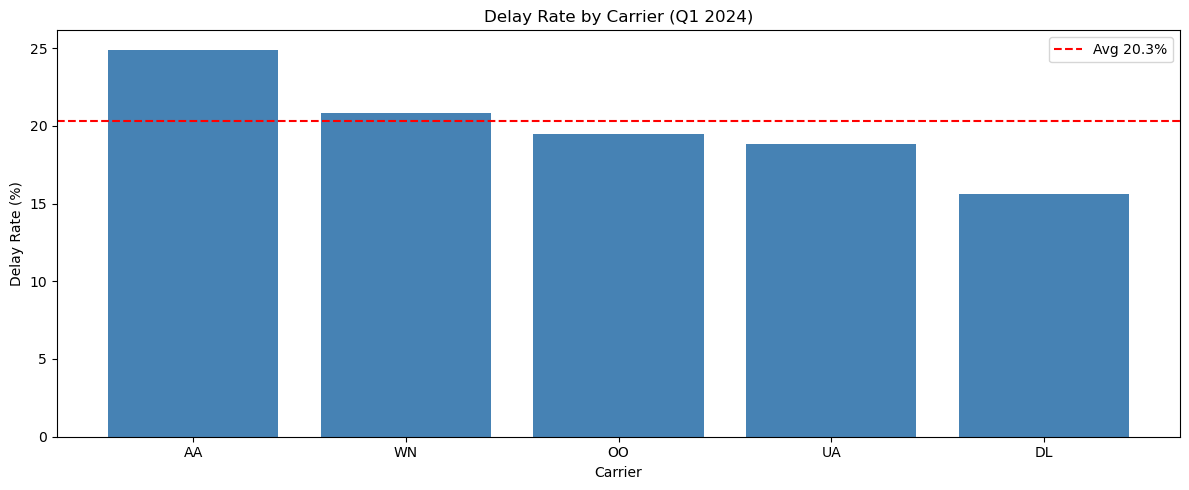

In [16]:
# delay rate by carrier:
carrier_stats = (df_eda.groupby("reporting_airline")["arrdel15"]
               .agg(["mean","count"])
               .query("count > 5000")
               .sort_values("mean", ascending=False))
               
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(carrier_stats.index, carrier_stats["mean"] * 100, color="steelblue")
ax.axhline(base_df["arrdel15"].mean() * 100, color="red",
         linestyle="--", label=f"Avg {base_df['arrdel15'].mean():.1%}")
ax.set_xlabel("Carrier")
ax.set_ylabel("Delay Rate (%)")
ax.set_title("Delay Rate by Carrier (Q1 2024)")
ax.legend()
plt.tight_layout()
plt.savefig("delay_by_carrier.png", dpi=100)
plt.show()

**Finding:** Delay Rate by Carrier

  - AA (American) highest at ~25% ,significantly above average
  - DL (Delta) lowest at ~15.5% , best performer
  - WN, OO, UA close to average
  - Only 5 carriers shown (>5000 flights) but there are 15 total
  - Decision: reporting_airline is a useful feature, use label encoding (15 unique values)


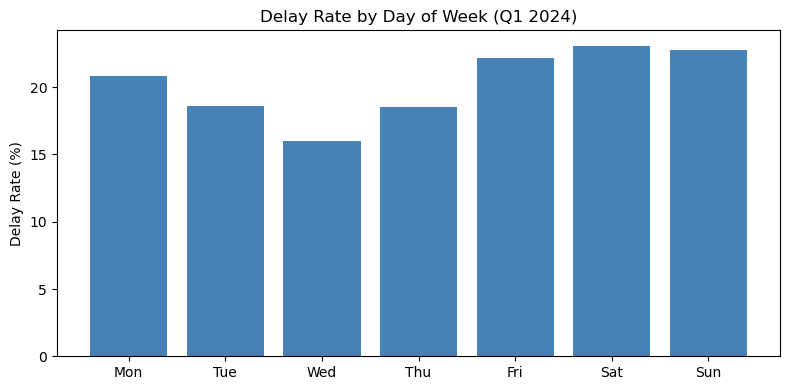

In [17]:
# delay rate by day of week:
dow_map = {1:"Mon", 2:"Tue", 3:"Wed", 4:"Thu", 5:"Fri", 6:"Sat", 7:"Sun"}
dow_stats = df_eda.groupby("dayofweek")["arrdel15"].mean() * 100
dow_stats.index = dow_stats.index.map(dow_map)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(dow_stats.index, dow_stats.values, color="steelblue")
ax.set_ylabel("Delay Rate (%)")
ax.set_title("Delay Rate by Day of Week (Q1 2024)")
plt.tight_layout()
plt.savefig("delay_by_dow.png", dpi=100)
plt.show()


**Finding:** Delay Rate by Day of Week                                                                                                                 

  - Wednesday lowest at ~16% — mid-week is least congested
  - Saturday highest at ~23% — weekend travel peaks
  - Friday and Sunday ~22% — weekend travel effect
  - Mon/Tue/Thu ~19-21% — typical weekday patterns
  - Range is 16-23% — meaningful variation, useful feature

  Decision: dayofweek is a useful feature, lets keep it. Also lets add is_weekend feature in preprocessing as Fri/Sat/Sun higher delay


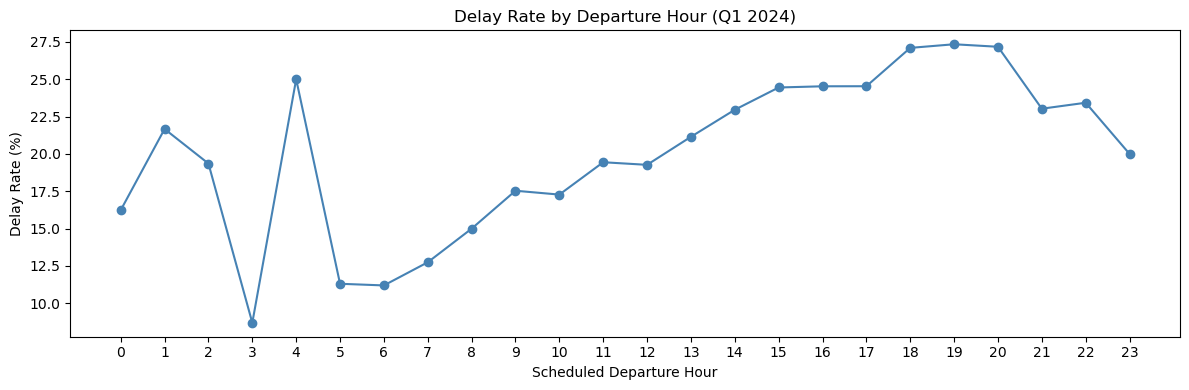

In [18]:
# delay rate by departure hour:
base_df["dep_hour"] = df_eda["crsdeptime"] // 100
hour_stats = base_df.groupby("dep_hour")["arrdel15"].mean() * 100

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(hour_stats.index, hour_stats.values, marker="o", color="steelblue")
ax.set_xlabel("Scheduled Departure Hour")
ax.set_ylabel("Delay Rate (%)")
ax.set_title("Delay Rate by Departure Hour (Q1 2024)")
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.savefig("delay_by_hour.png", dpi=100)
plt.show()

**Finding:** Delay Rate by Departure Hour

  - Early morning (5–6am) lowest delay ~11% — clean slate, no cascading delays
  - Evening (18–20) highest delay ~27% — delays accumulate through the day
  - Hours 0–4 are noisy — very few flights at those hours
Decision: dep_hour is a strong feature


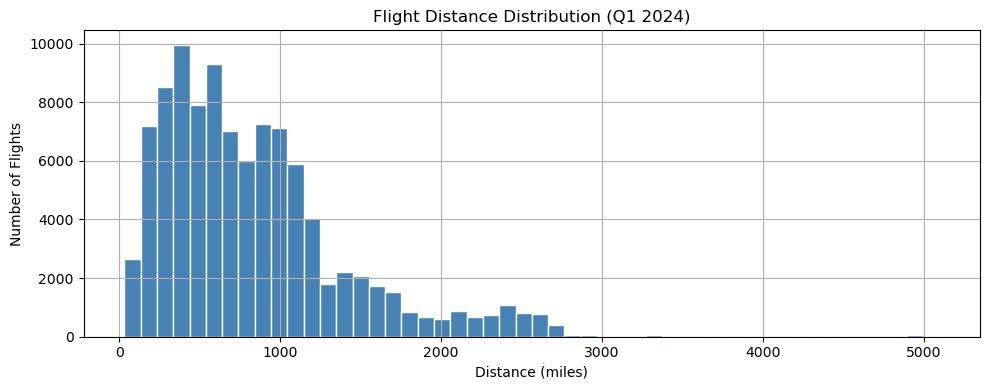

count    1.626052e+06
mean     8.365950e+02
std      5.910345e+02
min      3.100000e+01
25%      4.040000e+02
50%      6.960000e+02
75%      1.072000e+03
max      5.095000e+03
Name: distance, dtype: float64


In [19]:
# distance distribution:
fig, ax = plt.subplots(figsize=(10, 4))
df_eda["distance"].hist(bins=50, ax=ax, color="steelblue", edgecolor="white")
ax.set_xlabel("Distance (miles)") 
ax.set_ylabel("Number of Flights")
ax.set_title("Flight Distance Distribution (Q1 2024)")
plt.tight_layout()
plt.savefig("distance_dist.png", dpi=100)
plt.show()
print(base_df["distance"].describe())


  **Finding:** Distance Distribution

  - Right-skewed — most flights under 1000 miles, long tail to 5095 miles
  - No invalid values — min 31 miles is valid (short hops like LAX-SAN)
  - Max 5095 miles — likely Hawaii routes, valid
  - Decision: no outlier removal needed. Apply StandardScaler for Logistic Regression only, XGBoost doesn't need it



# Exploratory Data Analysis Findings Report

## 1. Dataset Overview

| Metric | Value |
|---|---|
| Raw files | 3 monthly CSVs (Jan, Feb, Mar 2024) |
| Total raw flights | 1,658,259 |
| After filtering cancelled + diverted | 1,626,052 |
| Cancelled flights removed | 28,511 |
| Diverted flights removed | 3,696 |
| Columns in raw data | 109 |
| Columns selected for modeling | 22 |
| Missing values in selected columns | 0 |

## 2. Class Balance (Target: ArrDel15)

| Class | Count | Percentage |
|---|---|---|
| On Time (0) | 1,295,574 | 80.4% |
| Delayed (1) | 330,478 | 19.6% |

**Finding:** Moderate class imbalance — 4:1 ratio.  
**Decision:** Set `scale_pos_weight=4` in XGBoost. Evaluate using F1-score and Recall, not accuracy alone. A naive model that always predicts on-time would achieve 80% accuracy — meaningless for this problem.


## 3. Missing Values

All 22 selected columns have **zero missing values** after filtering cancelled and diverted flights. No imputation required.

Columns excluded from selection that contain high nulls (post-flight only):
- `CarrierDelay`, `WeatherDelay`, `NASDelay`, `SecurityDelay`, `LateAircraftDelay` — only populated when flight is delayed, high leakage risk, excluded.

## 4. Cardinality of Categorical Columns

| Column | Unique Values | Encoding Strategy |
|---|---|---|
| `reporting_airline` | 15 | Label encoding |
| `origin` | 331 | Target encoding |
| `dest` | 331 | Target encoding |
| `originstate` | 52 | Label encoding |
| `deststate` | 52 | Label encoding |
| `deptimeblk` | 19 | Label encoding |

**Rationale:** Origin and Dest have 331 unique values each — one-hot encoding would create 331 columns each, causing dimensionality issues. Target encoding replaces each airport code with its historical delay rate, preserving predictive signal in a single column.


## 5. Numeric Feature Distributions

| Feature | Min | 25% | Median | 75% | Max | Mean |
|---|---|---|---|---|---|---|
| `distance` | 31 | 404 | 696 | 1,072 | 5,095 | 836 |
| `crselapsedtime` | 25 | 95 | 133 | 180 | 706 | 149 |
| `crsdeptime` | 1 | 910 | 1,320 | 1,732 | 2,359 | 1,325 |

**Distance finding:** Right-skewed distribution — majority of flights under 1,000 miles with a long tail to 5,095 miles (Hawaii/Alaska routes). No outliers — all values are valid domestic routes.  
**Decision:** No capping needed. Apply StandardScaler for Logistic Regression baseline only. XGBoost handles skewed distributions natively.

**CRSDepTime finding:** Stored as HHMM integer (e.g., 856 = 8:56am).  
**Decision:** Convert to `dep_hour = crsdeptime // 100` in preprocessing.


## 6. Delay Rate by Carrier

| Carrier | Delay Rate | vs Average |
|---|---|---|
| AA (American) | ~25% | +4.7% above avg |
| WN (Southwest) | ~21% | ~average |
| OO (SkyWest) | ~19.5% | slightly below |
| UA (United) | ~19% | slightly below |
| DL (Delta) | ~15.5% | -4.8% below avg |

**Overall average:** 20.3%

**Finding:** Significant variation across carriers (10 percentage point spread). AA is the worst performer, DL is the best. This confirms `reporting_airline` is a useful feature.  
**Decision:** Keep `reporting_airline` as a feature. Label encode (15 unique values).  
**Bias note:** Higher delay rates for certain carriers may reflect hub locations, route mix, or seasonal weather exposure rather than operational quality alone.



## 7. Delay Rate by Departure Hour

| Time Window | Hours | Delay Rate | Pattern |
|---|---|---|---|
| Early morning | 5–6am | ~11% | Lowest — clean slate, no cascading delays |
| Morning | 7–10am | 13–18% | Rising as day progresses |
| Midday | 11–14 | ~20% | Near average |
| Afternoon | 15–17 | ~25% | Delays accumulating |
| Evening | 18–20 | ~27% | Highest — full day of cascading delays |
| Night | 21–23 | ~22% | Slight drop as traffic thins |
| Overnight | 0–4 | Noisy | Very few flights, unreliable estimates |

**Finding:** Strong time-of-day pattern — delay risk nearly triples from early morning to evening. This is the cascading delay effect: late aircraft from earlier flights cause downstream delays.  
**Decision:** `dep_hour` is a strong predictive feature. Keep as continuous (0–23). Overnight hours (0–4) have small sample sizes — model will handle this naturally.



## 8. Delay Rate by Day of Week

| Day | Delay Rate |
|---|---|
| Wednesday | ~16% (lowest) |
| Tuesday | ~19% |
| Thursday | ~19% |
| Monday | ~21% |
| Friday | ~22% |
| Sunday | ~23% |
| Saturday | ~23% (highest) |

**Finding:** Weekend flights (Fri–Sun) have notably higher delay rates (~22–23%) vs mid-week (Wed ~16%). 7 percentage point spread across the week.  
**Decision:** Keep `dayofweek` as a feature. Add `is_weekend` binary feature (Sat/Sun = 1) to capture the weekend effect explicitly.



## 9. Leakage Analysis

### Target Leakage — columns to DROP before training

These columns are only known **after the flight lands** and directly leak the outcome:

| Column | Why it leaks |
|---|---|
| `arrdelay`, `arrdelayminutes` | IS the delay — direct target information |
| `depdelay`, `depdelayminutes` | Highly correlated with arrival delay |
| `dep_del15` | Departure delay indicator — leakage |
| `actualelapsedtime`, `airtime` | Actual vs scheduled — known post-flight |
| `taxiout`, `taxiin` | Actual taxi times — known post-flight |
| `wheelsoff`, `wheelson` | Actual wheel times — known post-flight |
| `carrierdelay`, `weatherdelay` | Delay cause breakdown — post-flight |
| `nasdelay`, `securitydelay`, `lateaircraftdelay` | Delay cause breakdown — post-flight |

### Temporal Leakage — prevented by time-based split

| Split | Data | Purpose |
|---|---|---|
| Train | January + February 2024 (40%) | Model learning |
| Validation | March 2024 first 10% | Hyperparameter tuning |
| Test | March 2024 next 10% | Final evaluation |
| Production simulation | March 2024 remaining 40% | Batch inference demo |

Training data is always earlier in time than validation/test data. No future data contaminates training.

### Preprocessing Leakage — prevented by fit-on-train-only rule

```
WRONG: scaler.fit(full_dataset)     ← leaks test statistics into scaler
RIGHT: scaler.fit(train_only)       ← scaler knows nothing about test data
       scaler.transform(train)
       scaler.transform(val)
       scaler.transform(test)
```


## 10. Feature Engineering Decisions

| Transformation | Input | Output | Reason |
|---|---|---|---|
| Discretization | `crsdeptime` (HHMM) | `dep_hour` (0–23) | Model-friendly integer hour |
| Binary extraction | `dayofweek` | `is_weekend` (0/1) | Captures Fri/Sat/Sun effect |
| Feature combination | `origin` + `dest` | `route` (e.g. LAX_JFK) | Route-level delay patterns |
| Target encoding | `origin`, `dest`, `route` | `origin_delay_rate`, `dest_delay_rate`, `route_delay_rate` | Encode high-cardinality cats with signal |
| Target encoding | `reporting_airline` | `carrier_delay_rate` | Historical carrier performance |
| Target encoding | `dep_hour` | `hour_delay_rate` | Historical hour performance |
| Drop | Leakage columns above | — | Prevent data leakage |
| Drop | `cancelled`, `diverted` | — | All values = 0 after filtering |
| Drop | `quarter` | — | Redundant with month |
| Drop | `distancegroup` | — | Redundant with distance |
| Drop | All `div*` columns | — | Only relevant for diverted flights |
| Drop | `*airportid`, `*seqid` | — | Numeric IDs redundant with airport codes |

## 11. Final Feature List for Model

```python
FINAL_FEATURES = [
    # time features
    "month", "dayofweek", "dayofmonth", "dep_hour", "is_weekend",
    
    # flight features
    "reporting_airline", "origin", "dest", "route",
    "distance", "crselapsedtime",
    
    # historical delay rates (computed from train only)
    "carrier_delay_rate",
    "origin_delay_rate",
    "dest_delay_rate",
    "route_delay_rate",
    "hour_delay_rate",
]

TARGET = "arrdel15"
```

## 12. Modeling Implications

| Consideration | Decision |
|---|---|
| Class imbalance | `scale_pos_weight=4` in XGBoost |
| Primary metrics | Recall + F1-score (business priority: catch delayed flights) |
| Secondary metrics | Precision, ROC-AUC, Confusion Matrix |
| Scaling | StandardScaler for Logistic Regression baseline only |
| XGBoost scaling | Not needed — tree models are scale-invariant |
| Feature importance | Logistic Regression coefficients + SHAP for XGBoost |
